<a href="https://colab.research.google.com/github/Akillesh-Suresh/IT480-FA26/blob/main/Lab2/Lab2_CNN_PetFinder_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *Akillesh Suresh & Ayden Laboswki*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [2]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>

In [3]:
# Your imports here
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [4]:
# Load and preprocess data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values (0-255) -> (0-1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode labels (0-9)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


*Your written answers for Part A:*

- Image size chosen and why: Fashion-MNIST already provides the images at a consistent size of 28x28 pixels, so no additional resizing was needed.
- Stratification decision and why: We did not perform a separate stratified train/test split because Fashion-MNIST already provides predefined training and test sets.


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [5]:
# Build your CNN model here

model = Sequential([
    # First convolution and pooling layer
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # Second convolution and pooling layer
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    # Flatten the feature maps before the Dense layers
    Flatten(),

    # Dense classifier
    Dense(64, activation="relu"),

    # 10 output neurons for the 10 Fashion-MNIST classes
    Dense(10, activation="softmax")
])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile your model here
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


*Your architecture justification (one paragraph):*

We used two Conv2D layers with MaxPooling2D after each one. The first convolutional layer uses 32 filters and the second uses 64 filters, following the convention of increasing the number of filters as the network gets deeper. We used 3x3 kernels because this is a common kernel size for detecting local features in images. MaxPooling2D reduces the size of the feature maps while keeping important features. After the convolutional layers, we used Flatten followed by a Dense layer with 64 neurons for classification. The output layer has 10 neurons with softmax activation because Fashion-MNIST has 10 different classes.




---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [7]:
# Train your model here (save the result as `history`)

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.8170 - loss: 0.5010 - val_accuracy: 0.8635 - val_loss: 0.3696
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.8781 - loss: 0.3340 - val_accuracy: 0.8865 - val_loss: 0.3163
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.8971 - loss: 0.2830 - val_accuracy: 0.8917 - val_loss: 0.2876
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9063 - loss: 0.2519 - val_accuracy: 0.8913 - val_loss: 0.2913
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9176 - loss: 0.2246 - val_accuracy: 0.9088 - val_loss: 0.2601
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9242 - loss: 0.2040 - val_accuracy: 0.9009 - val_loss: 0.2726
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9306 - loss: 0.1855 - val_accuracy: 0.9078 - val_loss: 0.2651
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9378 -

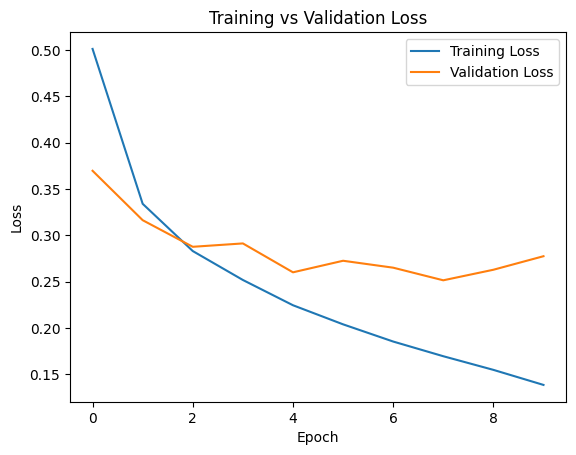

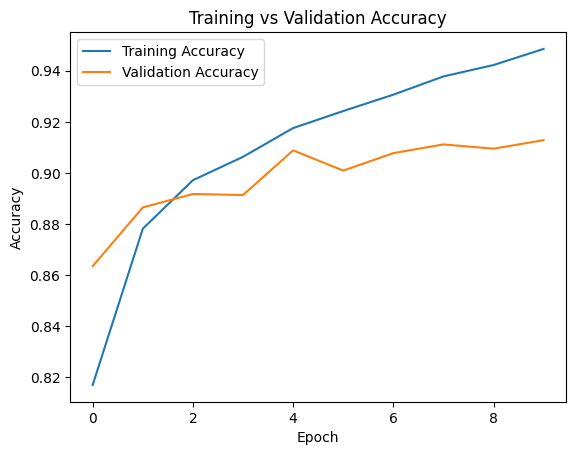

In [8]:
# Plot training vs. validation loss and accuracy here

import matplotlib.pyplot as plt


plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()



*Your fit diagnosis, with specific evidence from your curve:*
Our model shows signs of overfitting during the later epochs. Training accuracy continued to increase, reaching about 94.5%, while validation accuracy leveled off around 90%. Training loss also continued to decrease throughout training, while validation loss began increasing after reaching its lowest point around epoch 8. This growing difference between the training and validation results suggests that the model started learning the training data more specifically instead of continuing to improve on unseen data.



In [9]:
# Evaluate on the test set and report accuracy here

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9072 - loss: 0.2970
Test Loss: 0.29704996943473816
Test Accuracy: 0.9071999788284302


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*

We chose to improve our model using Dropout and Early Stopping because our baseline CNN showed signs of overfitting. The training accuracy continued to improve while the validation accuracy leveled off, and the validation loss began increasing during the later epochs. Dropout and Early Stopping can help reduce overfitting and improve how well the model generalizes to unseen data.




In [10]:
# Build your improved model here
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

improved_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

# Compile the improved model
improved_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [11]:
# Train your improved model here

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

improved_history = improved_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.7366 - loss: 0.7269 - val_accuracy: 0.8388 - val_loss: 0.4158
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.8248 - loss: 0.4859 - val_accuracy: 0.8702 - val_loss: 0.3435
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.8510 - loss: 0.4198 - val_accuracy: 0.8808 - val_loss: 0.3217
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.8620 - loss: 0.3864 - val_accuracy: 0.8857 - val_loss: 0.3020
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 27ms/step - accuracy: 0.8717 - loss: 0.3582 - val_accuracy: 0.8949 - val_loss: 0.2837
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.8799 - loss: 0.3378 - val_accuracy: 0.8977 - val_loss: 0.2724
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.8852 - loss: 0.3199 - val_accuracy: 0.9034 - val_loss: 0.2642
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.8909 -

---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy |90.72% |89.97%|
| Fit pattern (good/over/under) |Over |Good Fit |
| What changed |CNN|Add Droppout and early stopping |

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

In [12]:
# Evaluate your improved model and build a confusion matrix here

improved_loss, improved_accuracy = improved_model.evaluate(x_test, y_test)

print("Improved Test Loss:", improved_loss)
print("Improved Test Accuracy:", improved_accuracy)


y_pred = improved_model.predict(x_test)

y_true_classes = tf.argmax(y_test, axis=1)
y_pred_classes = tf.argmax(y_pred, axis=1)


confusion_matrix = tf.math.confusion_matrix(
    y_true_classes,
    y_pred_classes
)

print("Confusion Matrix:")
print(confusion_matrix.numpy())


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8997 - loss: 0.2743
Improved Test Loss: 0.27434954047203064
Improved Test Accuracy: 0.8996999859809875
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Confusion Matrix:
[[912   0  13  17   0   1  54   0   3   0]
 [  4 978   0  12   3   0   2   0   1   0]
 [ 13   0 860  10  49   0  67   0   1   0]
 [ 23   7  12 891  31   0  36   0   0   0]
 [  2   2  64  23 848   0  61   0   0   0]
 [  0   0   0   0   0 984   0  10   0   6]
 [186   1  82  26  76   0 623   0   6   0]
 [  0   0   0   0   0  12   0 974   0  14]
 [  4   1   5   4   4   1   7   0 974   0]
 [  0   0   0   0   0   4   1  42   0 953]]


*Your discussion of the confusion matrix:*

The improved model performed well on most Fashion-MNIST classes, but some classes were confused more often than others. Class 6 (Shirt) had the most misclassifications, with only 623 out of 1,000 images classified correctly. It was most commonly confused with class 0 (T-shirt/top), with 186 images classified incorrectly as that class. Shirts were also confused with class 2 (Pullover) and class 4 (Coat). This likely happens because these clothing categories have similar shapes and visual features. Other classes, such as class 5 (Sandal), class 7 (Sneaker), and class 8 (Bag), were classified much more accurately. Overall, adding Dropout and Early Stopping reduced the overfitting seen in the baseline model, although the test accuracy decreased slightly from 90.72% to 89.97%.




---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

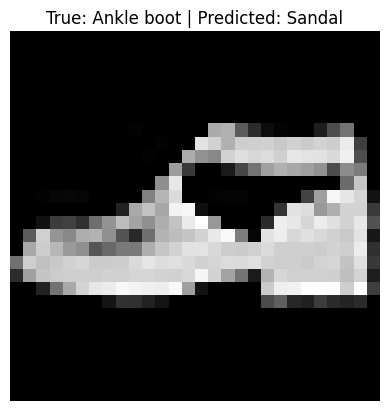

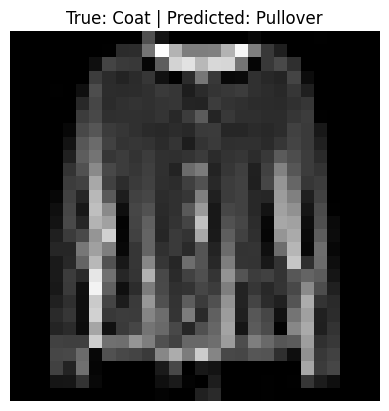

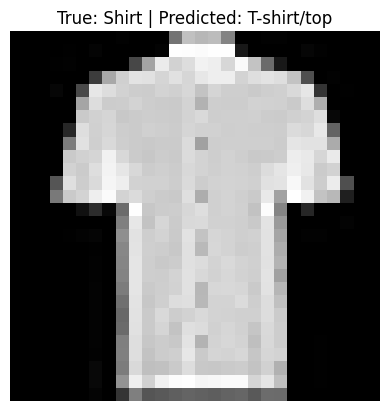

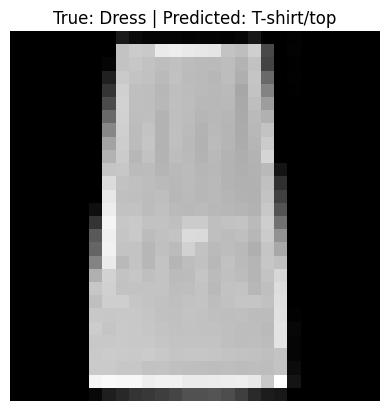

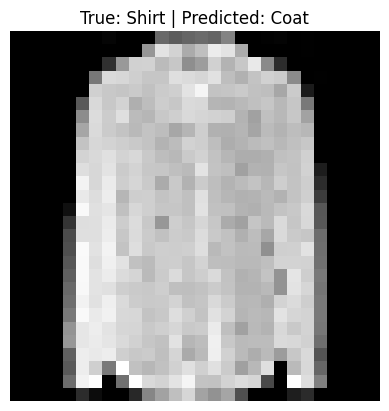

In [13]:
# Find and display misclassified images here

import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


misclassified = np.where(
    y_true_classes.numpy() != y_pred_classes.numpy()
)[0]


for i in misclassified[:5]:
    plt.figure()
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    true_label = class_names[y_true_classes.numpy()[i]]
    predicted_label = class_names[y_pred_classes.numpy()[i]]
    plt.title(
        f"True: {true_label} | Predicted: {predicted_label}"
    )
    plt.axis("off")
    plt.show()

*Your observations about the misclassified images:*

Most of the misclassified images have similar shapes and features to the classes the model predicted. For example, shirts, coats, pullovers, and T-shirts can look very similar in the low-resolution Fashion-MNIST images, making it difficult for the model to distinguish between them. The ankle boot was also mistaken for a sandal because both images share similar footwear features and shapes.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.